# 16장 이미지 인식의 꽃, 컨볼루션 신경망(CNN)

## 1. 이미지를 인식하는 원리

In [1]:
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical

import matplotlib.pyplot as plt
import sys

# MNIST 데이터셋을 불러와 학습셋과 테스트셋으로 저장합니다. 
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# 학습셋과 테스트셋이 각각 몇 개의 이미지로 되어 있는지 확인합니다. 
print("학습셋 이미지 수 : %d 개" % (X_train.shape[0]))
print("테스트셋 이미지 수 : %d 개" % (X_test.shape[0]))

11501568/11490434 [==============================] - 0s 0us/step
학습셋 이미지 수 : 60000 개
테스트셋 이미지 수 : 10000 개


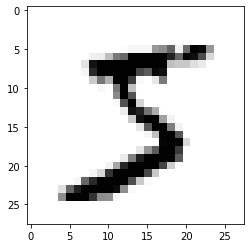

In [2]:
# 첫 번째 이미지를 확인해 봅시다.
plt.imshow(X_train[0], cmap='Greys')
plt.show()

In [3]:
# 이미지가 인식되는 원리를 알아봅시다.
for x in X_train[0]: # 28x28
    for i in x: # 하얀색 바탕 = 0, 색이 진할수록 255랑 가까움
        sys.stdout.write("%-3s" % i) # ""안에 있는 애는 띄어쓰기
    sys.stdout.write('\n')

0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  
0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  
0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  
0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  
0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  
0  0  0  0  0  0  0  0  0  0  0  0  3  18 18 18 12613617526 1662552471270  0  0  0  
0  0  0  0  0  0  0  0  30 36 94 15417025325325325325322517225324219564 0  0  0  0  
0  0  0  0  0  0  0  49 23825325325325325325325325325193 82 82 56 39 0  0  0  0  0  
0  0  0  0  0  0  0  18 2192532532532532531981822472410  0  0  0  0  0  0  0  0  0  
0  0  0  0  0  0  0  0  80 15610725325320511 0  43 1540  0  0  0  0  0  0  0  0  0  
0  0  0  0  0  0  0  0  0  14 1  15425390 0  0  0  0  0  0  0  0  0  0  0  0  0  0  
0  0  0  0  0  0  0  0  0  0  0  1392531902  0  0  0  0  0  0  0 

In [4]:
# 차원 변환 과정을 실습해 봅니다. 2D -> 1D
X_train = X_train.reshape(X_train.shape[0], 784) # 28x28 = 784
X_train = X_train.astype('float64') # normalization (range가 너무 커서)을 위해서 float으로 바꿈
X_train = X_train / 255 # [0, 255] -> [0, 1]

X_test = X_test.reshape(X_test.shape[0], 784).astype('float64') / 255

# 클래스 값을 확인해 봅니다.
print("class : %d " % (y_train[0])) # 숫자 5

# 바이너리화 과정을 실습해 봅니다.
y_train = to_categorical(y_train, 10) # 원핫인코딩이랑 같은 재질, 10개의 클래스가 있으니까 10
y_test = to_categorical(y_test, 10)

print(y_train[0]) # 5 -> 벡터값

class : 5 
[0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]


## 2. 딥러닝 기본 프레임 만들기 

In [5]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import ModelCheckpoint,EarlyStopping
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical

import matplotlib.pyplot as plt
import numpy as np
import os

# MNIST 데이터를 불러옵니다. 
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# 차원 변환 후, 테스트셋과 학습셋으로 나누어 줍니다.
X_train = X_train.reshape(X_train.shape[0], 784).astype('float32') / 255
X_test = X_test.reshape(X_test.shape[0], 784).astype('float32') / 255

y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

# 모델 구조를 설정합니다.
model = Sequential()
model.add(Dense(512, input_dim=784, activation='relu')) # 걍 512개 노드, 28x28개의 인풋
model.add(Dense(10, activation='softmax'))
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 512)               401920    
                                                                 
 dense_1 (Dense)             (None, 10)                5130      
                                                                 
Total params: 407,050
Trainable params: 407,050
Non-trainable params: 0
_________________________________________________________________


In [6]:
# 모델 실행 환경을 설정합니다.
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# 모델 최적화를 위한 설정 구간입니다.
modelpath="./MNIST_MLP.hdf5"
checkpointer = ModelCheckpoint(filepath=modelpath, monitor='val_loss', verbose=1, save_best_only=True)
early_stopping_callback = EarlyStopping(monitor='val_loss', patience=10) # 손실이 10번이상 나아지지않으면 멈추기 그리고나서 저장

# 모델을 실행합니다.
history = model.fit(X_train, y_train, validation_split=0.25, epochs=30, batch_size=200, verbose=0, callbacks=[early_stopping_callback,checkpointer])

# 테스트 정확도를 출력합니다.
print("\n Test Accuracy: %.4f" % (model.evaluate(X_test, y_test)[1]))


Epoch 1: val_loss improved from inf to 0.19404, saving model to ./MNIST_MLP.hdf5

Epoch 2: val_loss improved from 0.19404 to 0.14165, saving model to ./MNIST_MLP.hdf5

Epoch 3: val_loss improved from 0.14165 to 0.11376, saving model to ./MNIST_MLP.hdf5

Epoch 4: val_loss improved from 0.11376 to 0.10363, saving model to ./MNIST_MLP.hdf5

Epoch 5: val_loss improved from 0.10363 to 0.09306, saving model to ./MNIST_MLP.hdf5

Epoch 6: val_loss improved from 0.09306 to 0.08489, saving model to ./MNIST_MLP.hdf5

Epoch 7: val_loss did not improve from 0.08489

Epoch 8: val_loss improved from 0.08489 to 0.08430, saving model to ./MNIST_MLP.hdf5

Epoch 9: val_loss improved from 0.08430 to 0.08240, saving model to ./MNIST_MLP.hdf5

Epoch 10: val_loss did not improve from 0.08240

Epoch 11: val_loss did not improve from 0.08240

Epoch 12: val_loss did not improve from 0.08240

Epoch 13: val_loss improved from 0.08240 to 0.08204, saving model to ./MNIST_MLP.hdf5

Epoch 14: val_loss did not improv

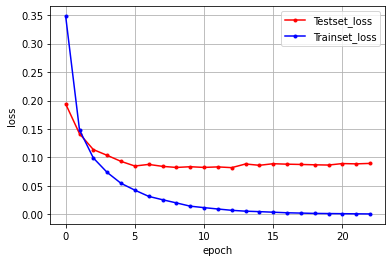

In [7]:
# 검증셋과 학습셋의 오차를 저장합니다. 
y_vloss = history.history['val_loss']
y_loss = history.history['loss']

# 그래프로 표현해 봅니다.
x_len = np.arange(len(y_loss))
plt.plot(x_len, y_vloss, marker='.', c="red", label='Testset_loss')
plt.plot(x_len, y_loss, marker='.', c="blue", label='Trainset_loss')

# 그래프에 그리드를 주고 레이블을 표시해 보겠습니다.
plt.legend(loc='upper right')
plt.grid()
plt.xlabel('epoch')
plt.ylabel('loss')
plt.show()

## 5. 컨볼루션 신경망 실행하기

In [8]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPooling2D
from tensorflow.keras.callbacks import ModelCheckpoint,EarlyStopping
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical

import matplotlib.pyplot as plt
import numpy as np

# 데이터를 불러옵니다.
(X_train, y_train), (X_test, y_test) = mnist.load_data()
X_train = X_train.reshape(X_train.shape[0], 28, 28, 1).astype('float32') / 255
X_test = X_test.reshape(X_test.shape[0], 28, 28, 1).astype('float32') / 255
y_train = to_categorical(y_train)
y_test = to_categorical(y_test)

# 컨볼루션 신경망의 설정
model = Sequential()
model.add(Conv2D(32, kernel_size=(3, 3), input_shape=(28, 28, 1), activation='relu')) # (28, 28, 1)에 28들은 데이터 가로세로 사이즈, 1은 흑백이라는 뜻 (컬러면 3); 맨 앞에 32라는 숫자는 kernel을 적용하는 과정을 몇번을 반복시킬 건지. 즉, convolution matrix를 몇개를 만들건지 정하는 거
model.add(Conv2D(64, (3, 3), activation='relu')) # 우리가 가지고있는 데이터가 2D니까 Conv2D; 또 한번 커널 적용
model.add(MaxPooling2D(pool_size=(2,2))) # 구역을 나눠서 각 matrix안에서 제일 큰 값을 추출하기
model.add(Dropout(0.25)) # 25%의 은닉층의 노드를 꺼주기
model.add(Flatten()) # 2D -> 1D
model.add(Dense(128,  activation='relu')) # 여기부터는 일반 딥러닝이랑 같은 구조
model.add(Dropout(0.5))
model.add(Dense(10, activation='softmax'))

# 모델의 실행 옵션을 설정합니다.
model.compile(loss='categorical_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])

# 모델 최적화를 위한 설정 구간입니다.
modelpath="./MNIST_CNN.hdf5"
checkpointer = ModelCheckpoint(filepath=modelpath, monitor='val_loss', verbose=1, save_best_only=True)
early_stopping_callback = EarlyStopping(monitor='val_loss', patience=10)

# 모델을 실행합니다.
history = model.fit(X_train, y_train, validation_split=0.25, epochs=30, batch_size=200, verbose=0, callbacks=[early_stopping_callback,checkpointer])

# 테스트 정확도를 출력합니다.
print("\n Test Accuracy: %.4f" % (model.evaluate(X_test, y_test)[1])) # 99% 이상 accuracy; 100%가 되기 힘들었던 이유는 사람이 봐도 읽기 힘든 손글씨가 포함 되어있었기 때문


Epoch 1: val_loss improved from inf to 0.08040, saving model to ./MNIST_CNN.hdf5

Epoch 2: val_loss improved from 0.08040 to 0.06223, saving model to ./MNIST_CNN.hdf5

Epoch 3: val_loss improved from 0.06223 to 0.05195, saving model to ./MNIST_CNN.hdf5

Epoch 4: val_loss improved from 0.05195 to 0.04767, saving model to ./MNIST_CNN.hdf5

Epoch 5: val_loss improved from 0.04767 to 0.04555, saving model to ./MNIST_CNN.hdf5

Epoch 6: val_loss improved from 0.04555 to 0.04509, saving model to ./MNIST_CNN.hdf5

Epoch 7: val_loss improved from 0.04509 to 0.04210, saving model to ./MNIST_CNN.hdf5

Epoch 8: val_loss improved from 0.04210 to 0.04204, saving model to ./MNIST_CNN.hdf5

Epoch 9: val_loss did not improve from 0.04204

Epoch 10: val_loss did not improve from 0.04204

Epoch 11: val_loss improved from 0.04204 to 0.04165, saving model to ./MNIST_CNN.hdf5

Epoch 12: val_loss did not improve from 0.04165

Epoch 13: val_loss did not improve from 0.04165

Epoch 14: val_loss did not improv

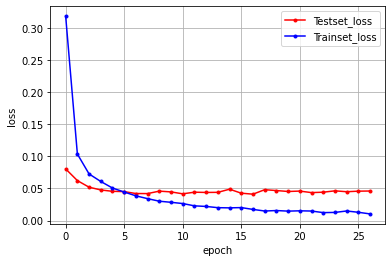

In [9]:
# 검증셋과 학습셋의 오차를 저장합니다.
y_vloss = history.history['val_loss']
y_loss = history.history['loss']

# 그래프로 표현해 봅니다.
x_len = np.arange(len(y_loss))
plt.plot(x_len, y_vloss, marker='.', c="red", label='Testset_loss')
plt.plot(x_len, y_loss, marker='.', c="blue", label='Trainset_loss')

# 그래프에 그리드를 주고 레이블을 표시하겠습니다.
plt.legend(loc='upper right')
plt.grid()
plt.xlabel('epoch')
plt.ylabel('loss')
plt.show()